# Custom data running

## Depth detection

In [1]:
import warnings
warnings.filterwarnings('ignore')

from src.images import get_imgs_from_video
import matplotlib.pyplot as plt

In [2]:
video_path = '/home/ant/user_data/video.mp4'
images = get_imgs_from_video(video_path, 2)
print(f"Images count: {len(images)}")

Images count: 79


### Depth Anything

In [3]:
from src.depth_anything import depth_anything
mono_depths = depth_anything(images)

Using cache found in /home/ant/.cache/torch/hub/facebookresearch_dinov2_main


78

Text(0.5, 1.0, 'Depth map')

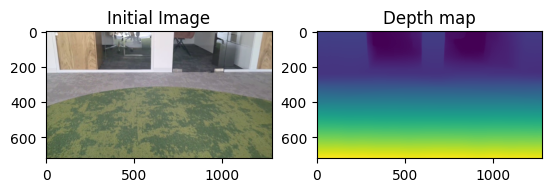

In [4]:
frame = 10

fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[frame])
ax[1].imshow(mono_depths[frame])
ax[0].set_title("Initial Image")
ax[1].set_title("Depth map")

### UniDepth

In [5]:
from src.uni_depth import uni_depth

In [6]:
metric_depths, fovs = uni_depth(images)

78

Text(0.5, 1.0, 'Depth map')

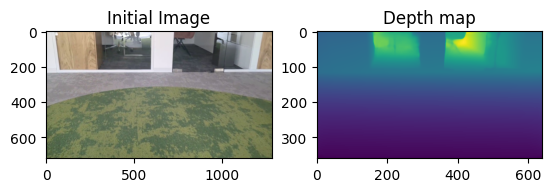

In [7]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[frame])
ax[1].imshow(metric_depths[frame])
ax[0].set_title("Initial Image")
ax[1].set_title("Depth map")

## MegaSAM

In [8]:
from src.megasam import megasam

In [ ]:
depths, disp_data, intrinsic, cam_c2w, mot_prob, poses, K = megasam(images, metric_depths, mono_depths, fovs)

************** UNIDEPTH FOV  64.96369643418222


1it [00:00,  8.94it/s]

checkpoints/megasam_final.pth
ADDING KEYFRAMES 2
ADDING KEYFRAMES 5
ADDING KEYFRAMES 7
ADDING KEYFRAMES 9
ADDING KEYFRAMES 11
ADDING KEYFRAMES 13
ADDING KEYFRAMES 15


17it [00:01,  8.65it/s]

ADDING KEYFRAMES 16
ADDING KEYFRAMES 17


...

67it [00:15,  3.78it/s]

ADDING KEYFRAMES 67


68it [00:15,  3.76it/s]

ADDING KEYFRAMES 68


69it [00:15,  3.91it/s]

In [ ]:
positions = cam_c2w[:, :3, 3]  
plt.figure(figsize=(8, 6))
plt.plot(positions[:, 0], positions[:, 2], marker='o')
plt.title("Camera Trajectory (Top View)")
plt.xlabel("X")
plt.ylabel("Z")
plt.axis("equal")
plt.grid()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[frame])
ax[1].imshow(depths[frame])
ax[0].set_title("Initial Image")
ax[1].set_title("Depth map")

## CVD optimization

In [ ]:
from src.cvd_opt import CVDconfig, preprocess_cvd, opt_cvd

In [ ]:
cvd_conf = CVDconfig(model='cvd_opt/raft-things.pth')
flow_masks, flows, iijj = preprocess_cvd(images, cvd_conf)

In [ ]:
disp_data_opt, depths_opt, intrinsic_opt, cam_c2w_opt = opt_cvd(images, disp_data, poses, flow_masks, flows, iijj, K, mot_prob)

In [ ]:
positions = cam_c2w_opt[:, :3, 3]  
plt.figure(figsize=(8, 6))
plt.plot(positions[:, 0], positions[:, 2], marker='o')
plt.title("Camera Trajectory (Top View)")
plt.xlabel("X")
plt.ylabel("Z")
plt.axis("equal")
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


fig, ax = plt.subplots(1, 3, figsize=(15, 3))

im1 = ax[0].imshow(images[0])
ax[0].set_title("RGB Image")

im2 = ax[1].imshow(depths_opt[0])
ax[1].set_title("Depth Map")

im3 = ax[2].plot(positions[:1, 0], positions[:1, 2], marker='o')
ax[2].set_title("Route")
ax[2].set_xlim(-0.5, 0.1)     
ax[2].set_ylim(-0.1, 0.5)  

def update(frame):
    im1.set_data(images[frame])
    im2.set_data(depths_opt[frame])
    im3[0].set_data(positions[:frame, 0], positions[:frame, 2])
    return [im1, im2]

ani = FuncAnimation(fig, update, frames=len(depths_opt), interval=100)
plt.close()  
HTML(ani.to_jshtml())

In [ ]:
ani = FuncAnimation(fig, update, frames=len(depths_opt), interval=100)

ani.save("animation.mp4", writer='ffmpeg', fps=10)